**Machine y Deep Learning**

Unidad 2

Práctica 3: Árboles de Regresión

*Facilitador: Dr. José Gabriel Rodríguez Rivas*

*Alumna: Carolina Alvarado Hernández*

Cargar datos y librerías

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
#https://drive.google.com/file/d/1LgW2AmS3kPRIKnx_trLVPi_RjsjVjnT_/view?usp=drive_link
file_id = "1LgW2AmS3kPRIKnx_trLVPi_RjsjVjnT_"
url = f"https://drive.google.com/uc?id={file_id}"
df = pd.read_csv(url)
df.head()

Mounted at /content/drive


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


Definir variables predictoras y variable objetivo

In [ ]:
X = df[['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']]
y = df['price']

Dividir en conjunto de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Entrenar árbol de regresión

profundidad máxima vertical = 4, if elses

In [ ]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=4)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

Evaluar el modelo

In [ ]:
y_pred_tree = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")

Error cuadrático medio (MSE): 9188294.38
Coeficiente de determinación (R²): 0.92


In [ ]:
rmse = np.sqrt(mse_tree)
print(rmse)

3031.219949198344


Comparar precios reales vs. predichos

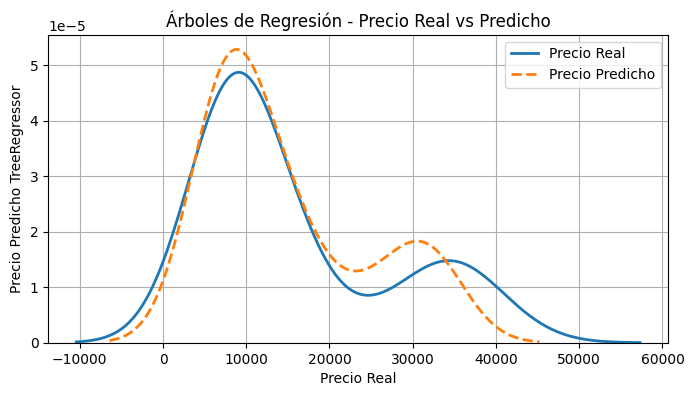

In [ ]:
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Árboles de Regresión - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()

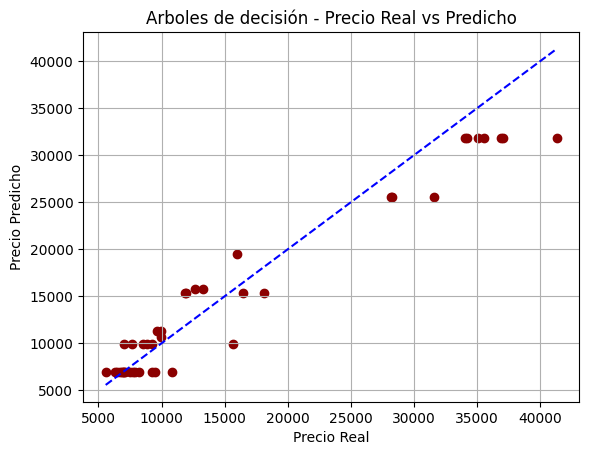

In [ ]:
plt.scatter(y_test, y_pred_tree, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

Impresión del Árbol de decision

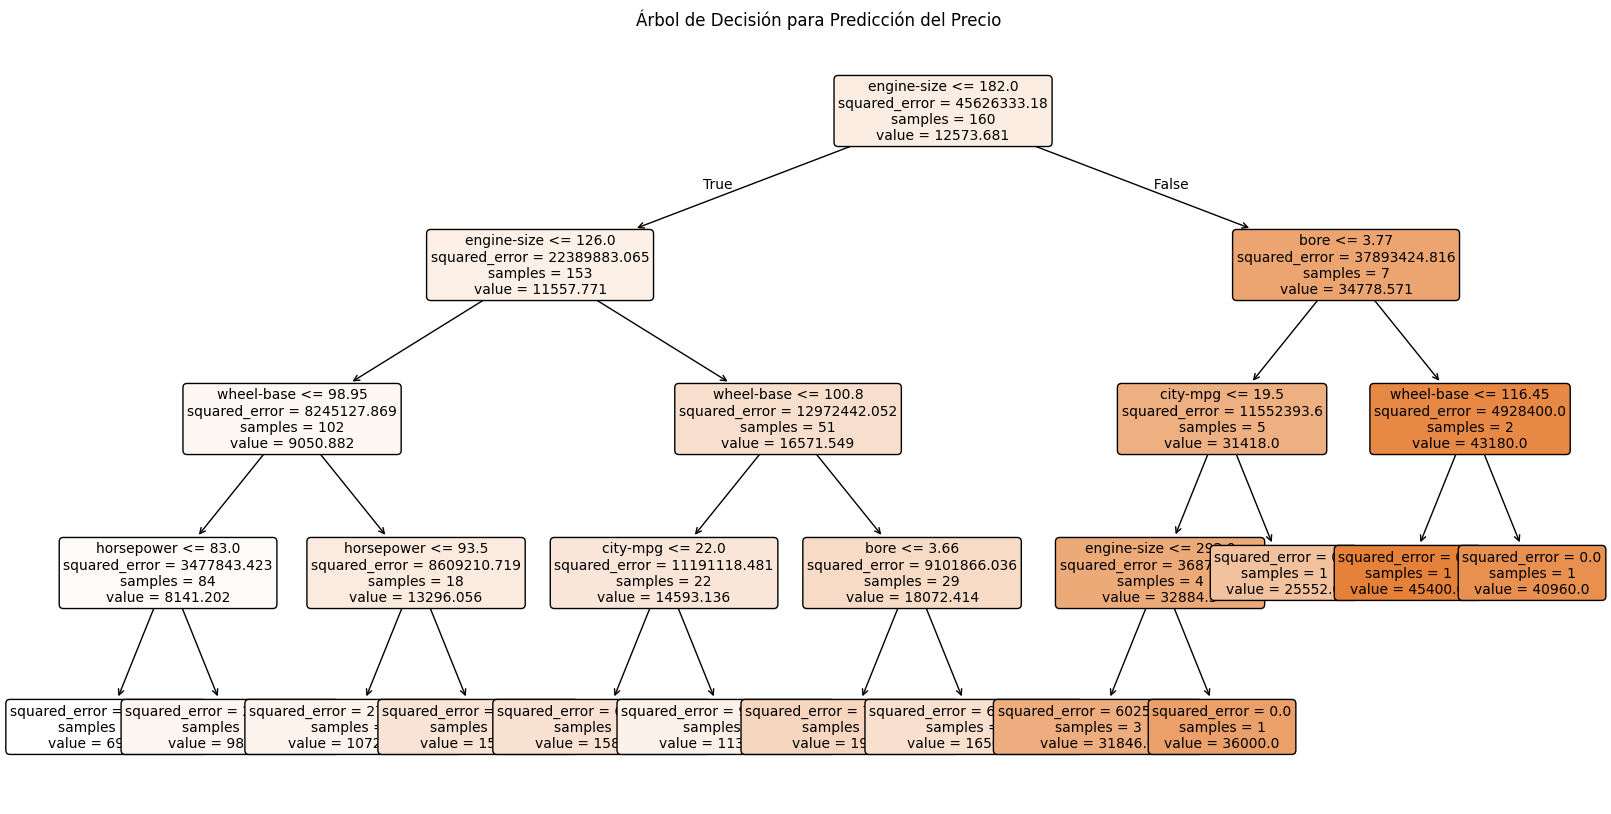

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
feature_names=X.columns,
filled=True,
rounded=True,
fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()


Ajustes de parámetros del árbol de decisión




In [ ]:
tree_model = DecisionTreeRegressor(random_state=42, max_depth=9)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"Coeficiente de determinación (R^2): {r2:.2f}")

rmse = np.sqrt(mse)
print(f"Raíz del Error cuadrático medio (RMSE): {rmse:.2f}")

Error cuadrático medio (MSE): 7896468.85
Coeficiente de determinación (R^2): 0.94
Raíz del Error cuadrático medio (RMSE): 2810.07


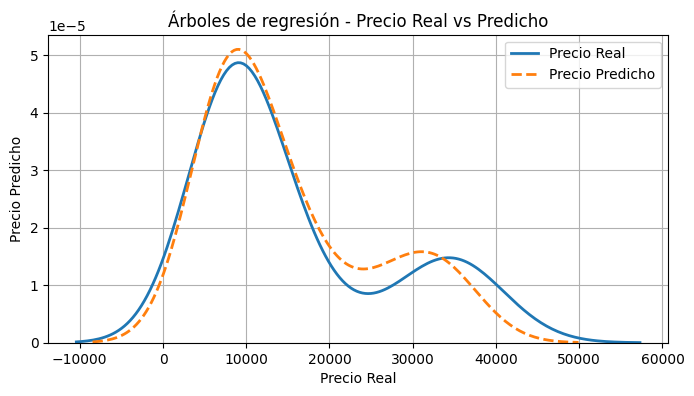

In [ ]:
plt.figure(figsize=(8,4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred, label='Precio Predicho', linewidth=2, linestyle='--')
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Árboles de regresión - Precio Real vs Predicho")
plt.grid(True)
plt.legend()
plt.show()

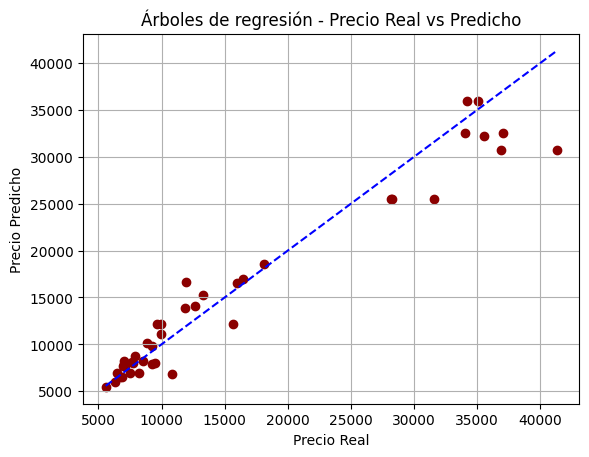

In [ ]:
plt.scatter(y_test, y_pred, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') #Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Árboles de regresión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

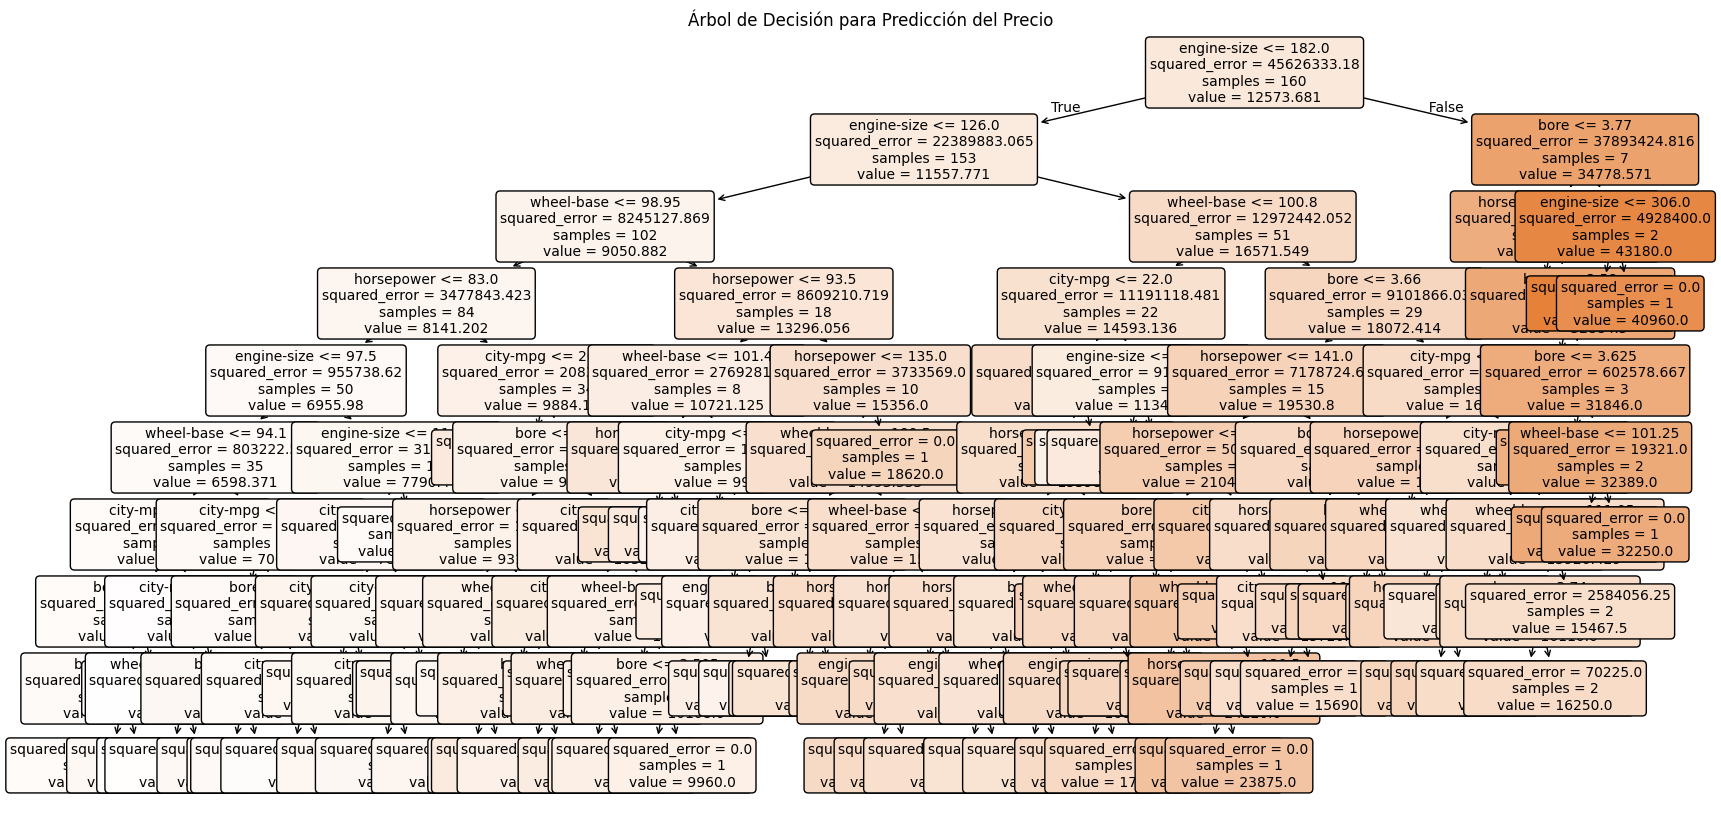

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(tree_model,
          feature_names=X.columns,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()

Ajustes de parámetros del árbol de decisión

Error cuadrático medio (MSE): 6207944.08
Coeficiente de determinación (R²): 0.95
2491.5746191891626


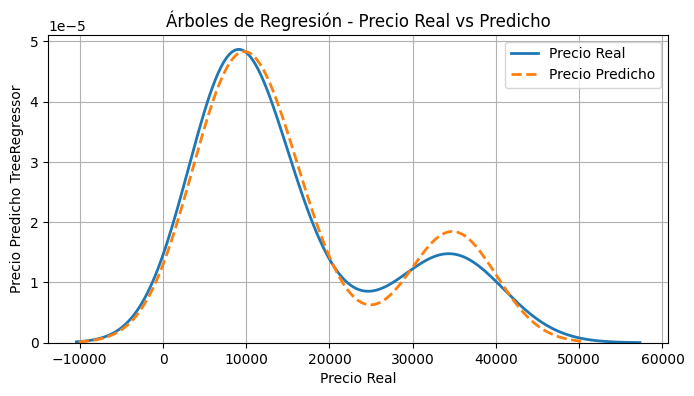

In [ ]:
tree_model = DecisionTreeRegressor(
random_state=42, max_depth=7,
min_samples_split=10, # Número mínimo de muestras requeridas para dividir un nodo.
min_samples_leaf=2, # Número mínimo de muestras que debe tener una hoja
max_features='sqrt', # Número máximo de características a considerar al dividir un nodo.
max_leaf_nodes=20 # Número máximo de hojas en el árbol.
)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)
print(f"Error cuadrático medio (MSE): {mse_tree:.2f}")
print(f"Coeficiente de determinación (R²): {r2_tree:.2f}")
# Calcular el RMSE (mas facil de interpretar que el MSE)
rmse = np.sqrt(mse_tree)
print(rmse)
# Comparación visual de distribuciones
plt.figure(figsize=(8, 4))
sns.kdeplot(y_test, label='Precio Real', linewidth=2)
sns.kdeplot(y_pred_tree, label='Precio Predicho', linewidth=2, linestyle='--')
plt.title('Árboles de Regresión - Precio Real vs Predicho')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho TreeRegressor')
plt.legend()
plt.grid(True)
plt.show()


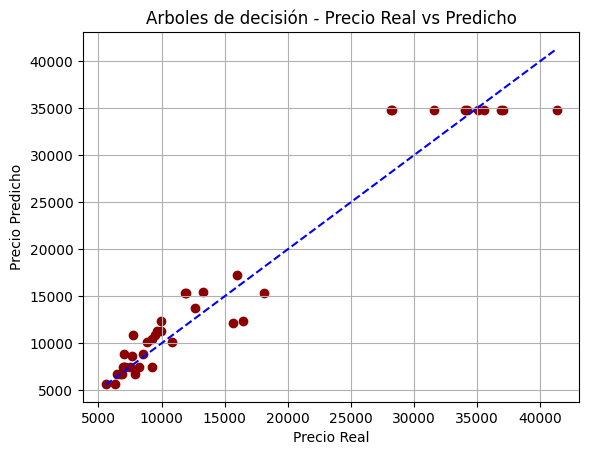

In [ ]:
plt.scatter(y_test, y_pred_tree, color='darkred')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--') # Línea ideal
plt.xlabel("Precio Real")
plt.ylabel("Precio Predicho")
plt.title("Arboles de decisión - Precio Real vs Predicho")
plt.grid(True)
plt.show()

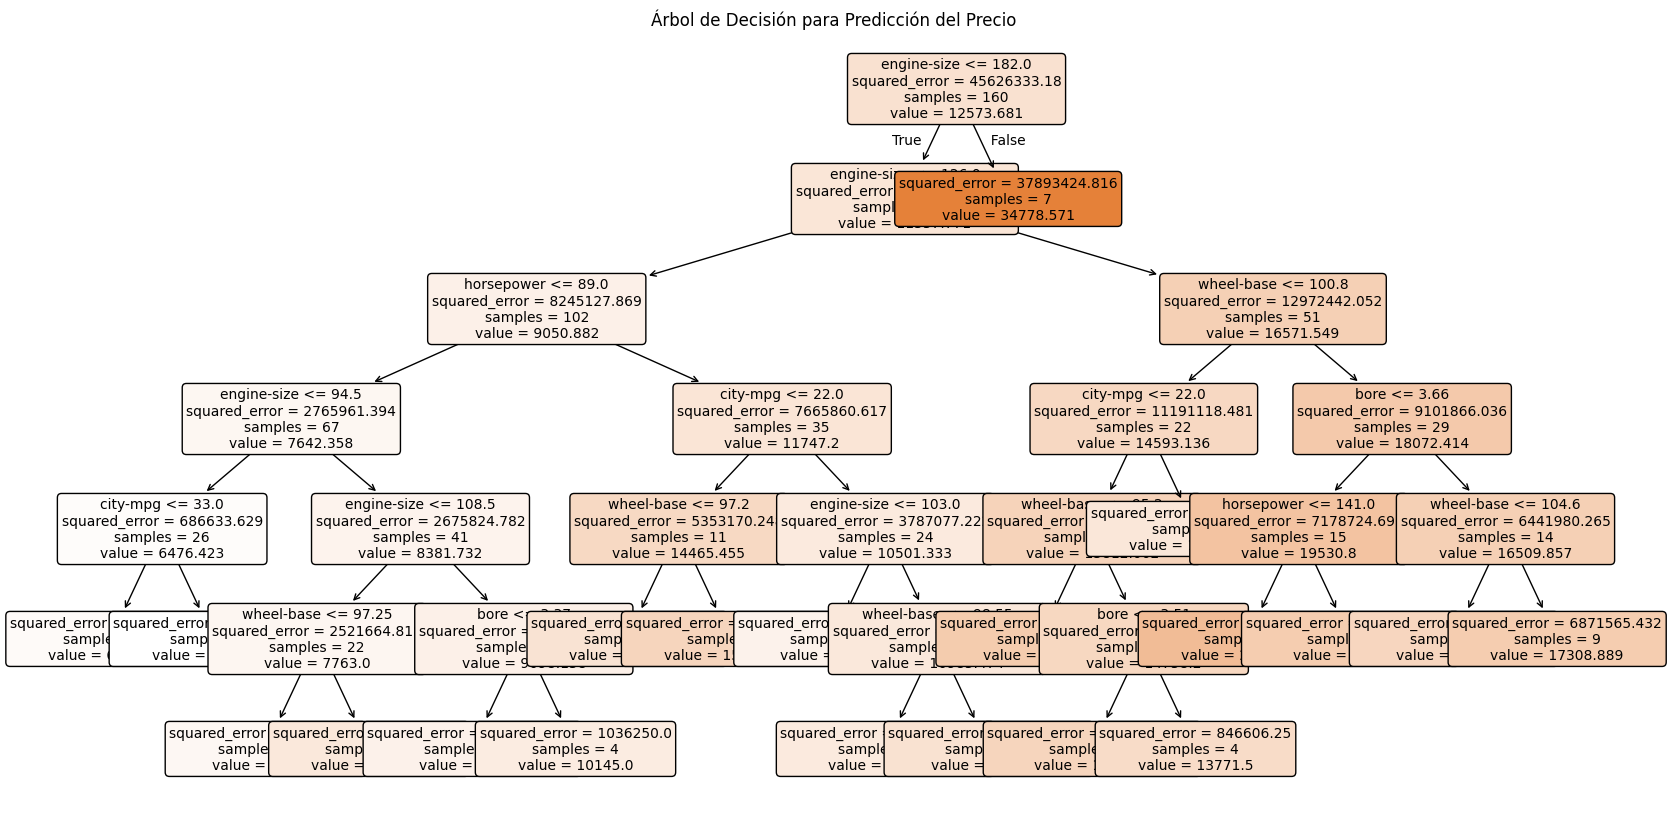

In [ ]:
# Visualizar el árbol de decisión
plt.figure(figsize=(20, 10))
plot_tree(tree_model,
feature_names=X.columns,
filled=True,
rounded=True,
fontsize=10)
plt.title("Árbol de Decisión para Predicción del Precio")
plt.show()